In [1]:
# Autoreload
%load_ext autoreload
%autoreload 2

from optimizer import Optimizer
from chromosome import Chromosome
from character import Character
from utils import get_item_set, elements
import os
from data import items, item_sets
import json

In [2]:
config = {
            "optimizer" : {
                "path" : "steamer-go-int-sue-crit-weapon",
                "language": "es",
                "population_size": 300,
                "num_parents_mating": 100, # Number of parents to mate, usually 1/3 of population size
                "num_generations": 400,
                "mutation_rate": 0.05,
                "crossover_rate": 0.8,
                "parent_selection_type": "tournament",  # Tournament Selection
                "tournament_size": 3,
                "exclusions": {
                    "items": [6894,
                              6895,
                              3080,
                              9031,
                              8575, # Ramboton
                              6980, # Vulbis
                            #   7754, # Dofus ocre
                              13344, # Dolmanax
                              ]  # Excluded items
                },
                "inclusions": {
                    "items": [
                              7754, # Dofus ocre
                              18043, # Dofus Abisal
                    ]
                },
                "preferences": {
                    "lower": {
                        12: {
                            "target": 12,  # AP
                            "strength": 0.9,  # Penalty for not meeting the target
                        },
                        8: {
                            "target": 5,  # MP
                            "strength": 0.9,  # Penalty for not meeting the target
                        },
                        29: {
                            "target": 80,  # Crit
                            "strength": 0.75,  # Penalty for not meeting the target
                        },
                        9: {
                            "target": 4000,  # Vit
                            "strength": 0.5,  # Penalty for not meeting the target
                        },
                        34 : {
                            "target": 15, # %res neutral
                            "strength": 0.1,  # Penalty for not meeting the target
                        },
                        37 : {
                            "target": 15, # %res fire
                            "strength": 0.1,  # Penalty for not meeting the target
                        },
                        16 : {
                            "target": 15, # %res air
                            "strength": 0.1,  # Penalty for not meeting the target
                        },
                        17 : {
                            "target": 15, # %res water
                            "strength": 0.1,  # Penalty for not meeting the target
                        },
                        63 : {
                            "target": 15, # %res range
                            "strength": 0.1,  # Penalty for not meeting the target
                        },
                        # 31 : {
                        #     "target": 6, # alcance
                        #     "strength": 0.75,  # Penalty for not meeting the target
                        # }
                    },
                    "upper": {}
                },
                "level_offset": 10,  # Level offset for items
                "objective": "weapon"  # Objective to optimize, can be "weapon" or "elements"
            },
            "character": {
                "level": 200,
                "scrolled": True,
                "exo": {
                    12:1, # Exo AP
                    # 8:1,  # Exo MP
                    29:3, # Exo crit
                    },
                "distributed_points": {
                    # 9: 995,  # Vitality
                },
                "elements" : [
                    # 36, # Agility,
                    22, # Chance
                    13, # Intelligence
                    45  # Strength
                ],
                "melee" : False,
                "ranged" : 3 # True or minimum range 
            },
        }

# Insert a list of initial user guesses, e.g., current set to use in optimization
initial_options = [
    # [
    # 15694, # Kidiboina
    # 11759, # Varita liana
    # 14168, # Capa pologia
    # 18700, # Cuadrifolio
    # 13673, # Lokulto
    # 14094, # Amuleto estrigido
    # 22206, # Alianza corrupcion
    # 22205, # Anillo corrupcion
    # 15699, # Cintaceo
    # 19610, # Zapautonimias
    # 16248, # Suertudo mayor
    # 16196, # Rabioso mayor
    # 18043, # Dofus Abisal
    # 694, # Dofus purpura
    # 739, # Dofus turquesa
    # 7043 # Dofus hielos
    # ]    
]
config["optimizer"]["initial_options"] = initial_options

if not os.path.exists(config["optimizer"]["path"]):
    os.makedirs(config["optimizer"]["path"], exist_ok=True)

with open(config["optimizer"]["path"] + '/config.json', 'w') as file:
    json.dump(config, file, indent=4)

In [3]:
import pandas as pd
dct = {}
for k,v in items.items():
    item_set = get_item_set(v,item_sets)
    dct[k] = {
        "name" : v["name"][config["optimizer"]["language"]],
        "set" : item_set["name"][config["optimizer"]["language"]] if item_set else None,
        "level" : v["level"]
    }
Items = pd.DataFrame.from_dict(dct, orient='index')
# Exclude items from the Gargandias set
config["optimizer"]["exclusions"]["items"] += Items[Items["set"].str.contains("Set de Gargandias",na=False,case=False)].index.tolist()

In [4]:
char = Character(**config["character"])
opt = Optimizer(char,
                 items,
                   item_sets,
                     **config["optimizer"])

Total items: 2652
Total item sets: 147
Total pools:
   16 with sizes [68, 26, 71, 71, 62, 81, 39, 88, 69, 411, 1, 1, 325, 325, 325, 325]
Total combinations: 10^28.69


In [5]:
solutions = opt.optimize(islands = 10, max_workers = 4)

/Users/jdtibochab/miniforge3/envs/other/lib/python3.10/site-packages/pygad/pygad.py:1149: UserWarning: Use the 'save_best_solutions' parameter with caution as it may cause memory overflow when either the number of generations or number of genes is large.
  warnings.warn("Use the 'save_best_solutions' parameter with caution as it may cause memory overflow when either the number of generations or number of genes is large.")
/Users/jdtibochab/miniforge3/envs/other/lib/python3.10/site-packages/pygad/pygad.py:1149: UserWarning: Use the 'save_best_solutions' parameter with caution as it may cause memory overflow when either the number of generations or number of genes is large.
  warnings.warn("Use the 'save_best_solutions' parameter with caution as it may cause memory overflow when either the number of generations or number of genes is large.")
/Users/jdtibochab/miniforge3/envs/other/lib/python3.10/site-packages/pygad/pygad.py:1149: UserWarning: Use the 'save_best_solutions' parameter with 

## Analysis

In [6]:
from analysis import Analyzer
analyzer = Analyzer(opt, solutions)
analyzer.run_analysis()

Number of candidate solutions: 22


In [7]:
analyzer.report_extended_results()

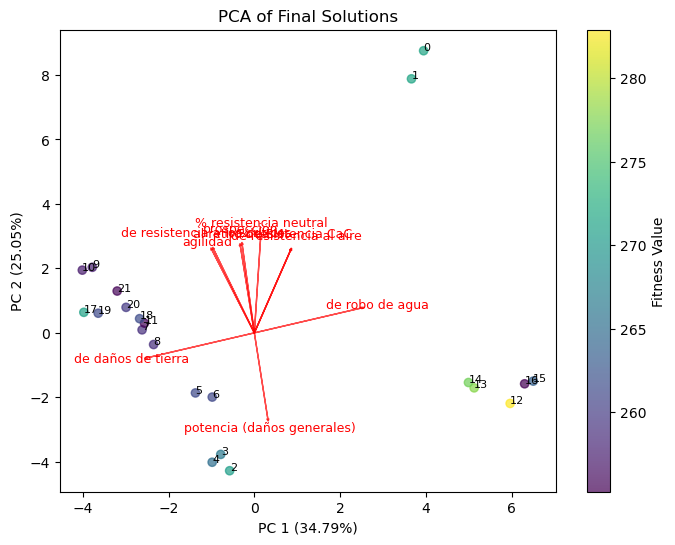

In [8]:
analyzer.plot_pca()

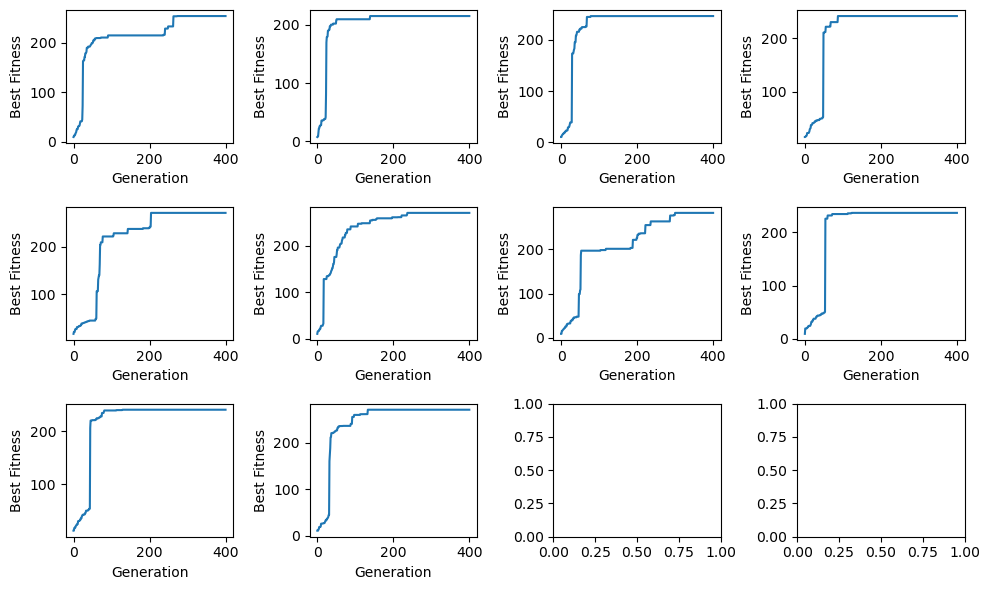

In [9]:
analyzer.report_generations()

In [10]:
assert False

AssertionError: 

In [25]:
# Current
chr = Chromosome([
    15694, # Kidiboina
    14168, # Capa pologia
    11759, # Varita liana
    18700, # Cuadrifolio
    13673, # Lokulto
    14094, # Amuleto estrigido
    22206, # Alianza corrupcion
    22205, # Anillo corrupcion
    15699, # Cintaceo
    19245, # Botas
    16248, # Suertudo mayor
    7754, # Dofus ocre
    18043, # Dofus Abisal
    694, # Dofus purpura
    739, # Dofus turquesa
    7043 # Dofus hielos
    ],
                 opt)
chr.fitness

290.55

In [23]:
Items[Items["name"].str.contains("estr.gido",case=False)]

,name,set,level
14094,Amuleto de estrígido,Set de estrígido,200
14096,Botas de estrígido,Set de estrígido,200
13986,Garra de estrígido,None,200
13987,Pico de estrígido,None,200
14095,Cinturón de estrígido,Set de estrígido,200


In [ ]:
chr.chromosome

[15694,
 14168,
 11759,
 18700,
 13673,
 14094,
 22206,
 22205,
 15699,
 19610,
 16248,
 16196,
 18043,
 694,
 739,
 7043]

In [ ]:
chr.totals_summary()

,description,value
0,Intercambiable:,0.0
8,PM,5.0
9,vitalidad,4050.0
10,sabiduría,385.0
12,PA,12.0
13,inteligencia,385.0
16,% resistencia al aire,41.0
17,% resistencia al agua,28.0
22,suerte,615.0
24,iniciativa,400.0


In [ ]:
Items[Items["name"].str.contains("kuko")]

In [ ]:
# Project
chr = Chromosome(
                 [
                    8993, # Espada
                    13641, 13642, # Noai
                    14161, 14162, 14169, # Charlatan
                    14092, 14093, 18718, # Kuko
                    13673, # Lokulto
                    739, 694, 7754, 737, 7043, 17078 # Dofus
                 ],
                 opt)
chr.fitness

In [ ]:
chr.set_summary()

In [ ]:
chr.set_summary()["set"].value_counts()

In [ ]:
chr.totals_summary(effect_descriptions)

In [ ]:
Items[Items["name"].str.contains("Chani")]

In [ ]:
item = items[21392]
# item = items[6981]

In [ ]:
chr.are_item_conditions_met(item)

In [ ]:
item

In [ ]:
Items

In [ ]:
lst

In [ ]:
lst[0][2]

In [ ]:
chr.are_item_conditions_met(items[11738])

In [ ]:
items[11738]["conditions"]

In [ ]:
chr.totals[8]

In [ ]:
lst = []
for i in items.values():
    if i["type"]["superTypeId"] not in [i[0] for i in opt.pool_types]:
        continue
    if i["conditions"]:
        print(opt.solution.are_item_conditions_met(i))
        lst.append((i,opt.solution.are_item_conditions_met(i)))

In [ ]:
lst[1]

In [ ]:
lst.count(True), lst.count(False)